<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 35 · Probability</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Random Variables &amp; Expectation 🎯</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:730px;line-height:1.6">A random variable turns outcomes into numbers, and once you have numbers you can average them. This notebook builds a distribution, computes its expected value and watches a sample mean converge to it, measures variance two ways, demonstrates linearity of expectation, and ends with expected loss, the quantity machine learning minimizes.</div>
  <div style="margin-top:16px;font-size:13px;color:#cbd5e1">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(35)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
INDIGO="#4f46e5"; PINK="#db2777"; GREEN="#059669"
print("ready")

ready


<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 1 · A RANDOM VARIABLE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">From outcomes to a distribution</div>
<div style="color:#4a5578;margin-top:6px">Let X be the sum of two fair dice. X is a random variable: it assigns a number to every outcome. Its probability mass function (PMF) lists P(X = x) for each value.</div>
</div>

In [2]:
from collections import Counter
sums = [a+b for a in range(1,7) for b in range(1,7)]   # all 36 equally likely outcomes
counts = Counter(sums)
values = sorted(counts)
pmf = np.array([counts[v]/36 for v in values])
for v,p in zip(values,pmf):
    print(f"P(X={v:2d}) = {counts[v]}/36 = {p:.4f}")
print(f"\nsum of PMF = {pmf.sum():.4f}  (a valid distribution)")

P(X= 2) = 1/36 = 0.0278
P(X= 3) = 2/36 = 0.0556
P(X= 4) = 3/36 = 0.0833
P(X= 5) = 4/36 = 0.1111
P(X= 6) = 5/36 = 0.1389
P(X= 7) = 6/36 = 0.1667
P(X= 8) = 5/36 = 0.1389
P(X= 9) = 4/36 = 0.1111
P(X=10) = 3/36 = 0.0833
P(X=11) = 2/36 = 0.0556
P(X=12) = 1/36 = 0.0278

sum of PMF = 1.0000  (a valid distribution)


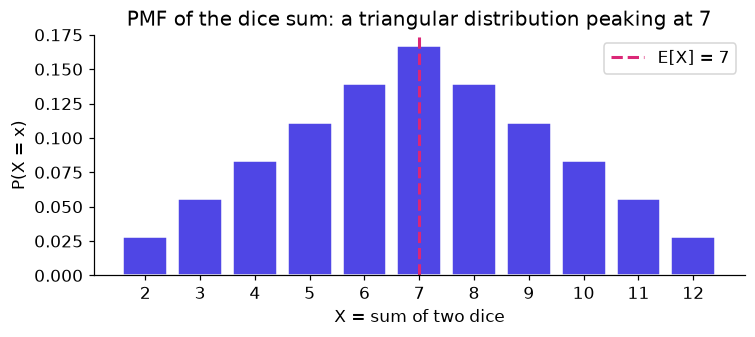

In [3]:
fig,ax=plt.subplots(figsize=(7,3.2))
ax.bar(values, pmf, color=INDIGO, edgecolor="white")
ax.axvline(7, color=PINK, lw=2, ls="--", label="E[X] = 7")
ax.set_xticks(values); ax.set_xlabel("X = sum of two dice"); ax.set_ylabel("P(X = x)")
ax.set_title("PMF of the dice sum: a triangular distribution peaking at 7"); ax.legend()
plt.tight_layout(); plt.show()

The PMF is a complete description of the random variable: every probability is between 0 and 1, and together they sum to 1. The distribution is symmetric and peaks at 7, which is a strong hint about where its average sits.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 2 · EXPECTED VALUE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The long-run average</div>
<div style="color:#4a5578;margin-top:6px">The expected value E[X] is the probability-weighted average of the values: E[X] = sum of x times P(X = x). It is the balance point of the distribution, and the value a sample mean converges to.</div>
</div>

In [4]:
EX = sum(v*p for v,p in zip(values,pmf))
print(f"E[X] = sum x*P(x) = {EX:.4f}")

# Law of Large Numbers: the sample mean closes in on E[X]
rolls = rng.integers(1,7,size=(200_000,2)).sum(axis=1)
print(f"mean of 200,000 simulated sums = {rolls.mean():.4f}  (theory 7)")

E[X] = sum x*P(x) = 7.0000
mean of 200,000 simulated sums = 6.9989  (theory 7)


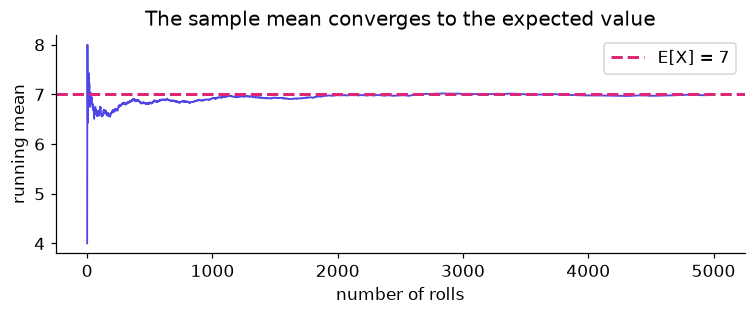

In [5]:
running = np.cumsum(rolls)/np.arange(1,len(rolls)+1)
fig,ax=plt.subplots(figsize=(7,3))
ax.plot(running[:5000], color=INDIGO, lw=1.2)
ax.axhline(7, color=PINK, lw=2, ls="--", label="E[X] = 7")
ax.set_xlabel("number of rolls"); ax.set_ylabel("running mean")
ax.set_title("The sample mean converges to the expected value"); ax.legend()
plt.tight_layout(); plt.show()

E[X] = 7. The expected value need not be an attainable outcome (you cannot roll a single value of 7 on one die), it is the long-run average. The running mean wanders early, then settles onto 7, the Law of Large Numbers from Chapter 30 in action.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 3 · VARIANCE &amp; STANDARD DEVIATION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Measuring the spread</div>
<div style="color:#4a5578;margin-top:6px">Expectation gives the center; variance gives the spread. Var(X) = E[(X - mu)^2], the average squared distance from the mean. Two formulas, one answer.</div>
</div>

In [6]:
mu = EX
var_def  = sum((v-mu)**2 * p for v,p in zip(values,pmf))     # definition
EX2      = sum(v**2 * p for v,p in zip(values,pmf))
var_short = EX2 - mu**2                                       # shortcut: E[X^2] - (E[X])^2
sd = var_def**0.5
print(f"E[X^2]                 = {EX2:.4f}")
print(f"Var(X) = E[(X-mu)^2]   = {var_def:.4f}")
print(f"Var(X) = E[X^2]-mu^2   = {var_short:.4f}   (same answer)")
print(f"SD(X)  = sqrt(Var)     = {sd:.4f}")

E[X^2]                 = 54.8333
Var(X) = E[(X-mu)^2]   = 5.8333
Var(X) = E[X^2]-mu^2   = 5.8333   (same answer)
SD(X)  = sqrt(Var)     = 2.4152


Both formulas give Var(X) = 5.8333, so SD(X) &approx; 2.415. The shortcut E[X&sup2;] &minus; &mu;&sup2; is almost always easier to compute by hand. Standard deviation is in the same units as X, so it is the more interpretable measure of spread.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 4 · LINEARITY OF EXPECTATION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Add the averages, even when dependent</div>
<div style="color:#4a5578;margin-top:6px">E[X + Y] = E[X] + E[Y], ALWAYS, even when X and Y are dependent. This is one of the most useful facts in probability. The matching problem shows it off.</div>
</div>

In [7]:
# Secret Santa: n people each draw a name at random. How many draw their own?
def matches(n): return int((rng.permutation(n) == np.arange(n)).sum())
for n in (5, 20, 100):
    avg = np.mean([matches(n) for _ in range(50_000)])
    print(f"n={n:3d}: average number who draw their own name = {avg:.3f}")
print("\nExpected matches = n * (1/n) = 1, for every n (linearity of indicators).")

n=  5: average number who draw their own name = 0.995


n= 20: average number who draw their own name = 0.991


n=100: average number who draw their own name = 1.006

Expected matches = n * (1/n) = 1, for every n (linearity of indicators).


Each person matches their own name with probability 1/n, so by linearity the expected total is n &times; (1/n) = **1**, no matter how many people, and despite the draws being dependent. Linearity also gives the scaling rule E[aX + b] = a&middot;E[X] + b: a payoff of 2X+1 on one die has expected value 2(3.5)+1 = 8.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 5 · EXPECTED LOSS IN MACHINE LEARNING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The quantity models minimize</div>
<div style="color:#4a5578;margin-top:6px">Training a model means minimizing expected loss (risk). For a classifier, a common loss is -log(p) on the true class. The better model has the lower expected loss.</div>
</div>

In [8]:
# true labels and two models' predicted probability for the TRUE class
rng2 = np.random.default_rng(7)
p_true_A = rng2.uniform(0.45, 0.75, size=10_000)    # mediocre model
p_true_B = rng2.uniform(0.70, 0.98, size=10_000)    # better model

loss_A = -np.log(p_true_A).mean()    # expected cross-entropy loss
loss_B = -np.log(p_true_B).mean()
print(f"E[loss] model A = {loss_A:.3f}")
print(f"E[loss] model B = {loss_B:.3f}")
print(f"\nLower expected loss wins: model {'B' if loss_B<loss_A else 'A'}")

E[loss] model A = 0.521
E[loss] model B = 0.178

Lower expected loss wins: model B


Cross-entropy loss is literally an **expected value**: the average of &minus;log(p) over the data. Gradient descent nudges the parameters to push that expectation down. The same machinery powers reinforcement learning, where the agent maximizes **expected reward** E[R], and Monte Carlo methods, which estimate any expectation by averaging samples (exactly what every simulation in this notebook did).

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You turned outcomes into a random variable and its PMF, computed an expected value and watched a sample mean converge to it, measured variance two ways, proved linearity of expectation on a dependent problem, and minimized an expected loss the way a model does. Center (expectation) and spread (variance) are the two numbers that summarize any random variable.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>